<a href="https://colab.research.google.com/github/Podisti/KNN-bird-clasifier/blob/main/KNN_Bird_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# connection to one drive for the storing of weights during training
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# dataset download
import kagglehub
path = kagglehub.dataset_download("veeralakrishna/200-bird-species-with-11788-images")
print("Data ready at:", path)

Using Colab cache for faster access to the '200-bird-species-with-11788-images' dataset.
Data ready at: /kaggle/input/200-bird-species-with-11788-images


In [13]:
# dataset extraction
import os
import tarfile

# source and destination directory
download_dir = path
extract_dir = '/content/CUB_200_dataset'
# create dst if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)
# files in the source
archives = ['CUB_200_2011.tgz', 'segmentations.tgz']

print(f"Starting extraction to: {extract_dir}\n")

# extraction
for archive_name in archives:
    archive_path = os.path.join(download_dir, archive_name)
    print(archive_path)

    # Check if the file actually exists before extracting
    if os.path.exists(archive_path):
        print(f"Extracting {archive_name}...")
        with tarfile.open(archive_path, 'r:gz') as tar:
            tar.extractall(path=extract_dir)
        print(f"Successfully extracted {archive_name}")
    else:
        print(f"Warning: Could not find {archive_name}")

print("\nExtraction completed")

extracted_path = extract_dir

Starting extraction to: /content/CUB_200_dataset

/kaggle/input/200-bird-species-with-11788-images/CUB_200_2011.tgz
Extracting CUB_200_2011.tgz...


/tmp/ipykernel_7185/1903717810.py:24: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


Successfully extracted CUB_200_2011.tgz
/kaggle/input/200-bird-species-with-11788-images/segmentations.tgz
Extracting segmentations.tgz...
Successfully extracted segmentations.tgz

Extraction completed


In [14]:
# =============================
# ADD "NONE" CLASS TO DATASET
# =============================
import os
import shutil
import random
import kagglehub

base_path = os.path.join(extracted_path, "CUB_200_2011")

images_dir = os.path.join(base_path, "images")
classes_file = os.path.join(base_path, "classes.txt")
images_file = os.path.join(base_path, "images.txt")
labels_file = os.path.join(base_path, "image_class_labels.txt")
split_file = os.path.join(base_path, "train_test_split.txt")

NEW_CLASS_ID = 201
NEW_CLASS_NAME = "none"
NEW_CLASS_FOLDER = f"{NEW_CLASS_ID}.{NEW_CLASS_NAME}"

none_dir = os.path.join(images_dir, NEW_CLASS_FOLDER)
os.makedirs(none_dir, exist_ok=True)

print(f"Created folder: {none_dir}")

# =============================
# REGISTER NEW CLASS
# =============================
with open(classes_file, "r") as f:
    content = f.read()

if f"{NEW_CLASS_ID} {NEW_CLASS_NAME}" not in content:
    with open(classes_file, "a") as fa:
        fa.write(f"\n{NEW_CLASS_ID} {NEW_CLASS_NAME}")

# =============================
# GET NEXT IMAGE ID
# =============================
with open(images_file, "r") as f:
    lines = f.readlines()

next_id = int(lines[-1].split()[0]) + 1


# =============================
# DOWNLOAD INTEL DATASET
# =============================
intel_path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Intel dataset at:", intel_path)

train_root = os.path.join(intel_path, "seg_train", "seg_train")

categories = [
    d for d in os.listdir(train_root)
    if os.path.isdir(os.path.join(train_root, d))
]

print("Categories:", categories)


# =============================
# SAMPLE ~1000 IMAGES TOTAL
# =============================
TARGET_TOTAL = 1000
per_category = TARGET_TOTAL // len(categories)

copied_count = 0

for category in categories:
    category_path = os.path.join(train_root, category)

    images = [
        f for f in os.listdir(category_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if len(images) == 0:
        continue

    sample = random.sample(images, min(per_category, len(images)))

    for img_name in sample:
        src = os.path.join(category_path, img_name)

        new_name = f"{category}_{img_name}"
        dst = os.path.join(none_dir, new_name)

        shutil.copy(src, dst)
        copied_count += 1

print(f"Copied {copied_count} images into 'none' class")


# =============================
# REGISTER NEW IMAGES
# =============================
existing_entries = set()

with open(images_file, "r") as f:
    for line in f:
        existing_entries.add(line.strip().split()[1])

image_files = [
    f for f in os.listdir(none_dir)
    if f"{NEW_CLASS_FOLDER}/{f}" not in existing_entries
]

with open(images_file, "a") as f_img, \
     open(labels_file, "a") as f_lbl, \
     open(split_file, "a") as f_split:

    for img_name in image_files:
        rel_path = f"{NEW_CLASS_FOLDER}/{img_name}"

        f_img.write(f"{next_id} {rel_path}\n")
        f_lbl.write(f"{next_id} {NEW_CLASS_ID}\n")

        is_train = 1 if random.random() < 0.8 else 0
        f_split.write(f"{next_id} {is_train}\n")

        next_id += 1

print("Finished adding 'none' class")

Created folder: /content/CUB_200_dataset/CUB_200_2011/images/201.none
Using Colab cache for faster access to the 'intel-image-classification' dataset.
Intel dataset at: /kaggle/input/intel-image-classification
Categories: ['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']
Copied 996 images into 'none' class
Finished adding 'none' class


In [15]:
# dataset exploration
import os
from PIL import Image
import numpy as np

dataset_path = extracted_path
print(extracted_path)

image_extensions = {'.jpg', '.jpeg', '.png'}
classes = set()
total_images = 0
image_sizes = []

print("Exploring dataset...\n")

# go through all files
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if os.path.splitext(file)[1].lower() in image_extensions:
            total_images += 1

            # folders = bird names
            class_name = os.path.basename(root)
            classes.add(class_name)

            # sizes
            img_path = os.path.join(root, file)
            try:
                with Image.open(img_path) as img:
                    image_sizes.append(img.size)
            except Exception as e:
                pass

print(f"Total number of images: {total_images}")
print(f"Total number of categories: {len(classes)}")

print("\nClass names:", list(classes)[:5])

/content/CUB_200_dataset
Exploring dataset...

Total number of images: 25501
Total number of categories: 201

Class names: ['125.Lincoln_Sparrow', '189.Red_bellied_Woodpecker', '081.Pied_Kingfisher', '058.Pigeon_Guillemot', '161.Blue_winged_Warbler']


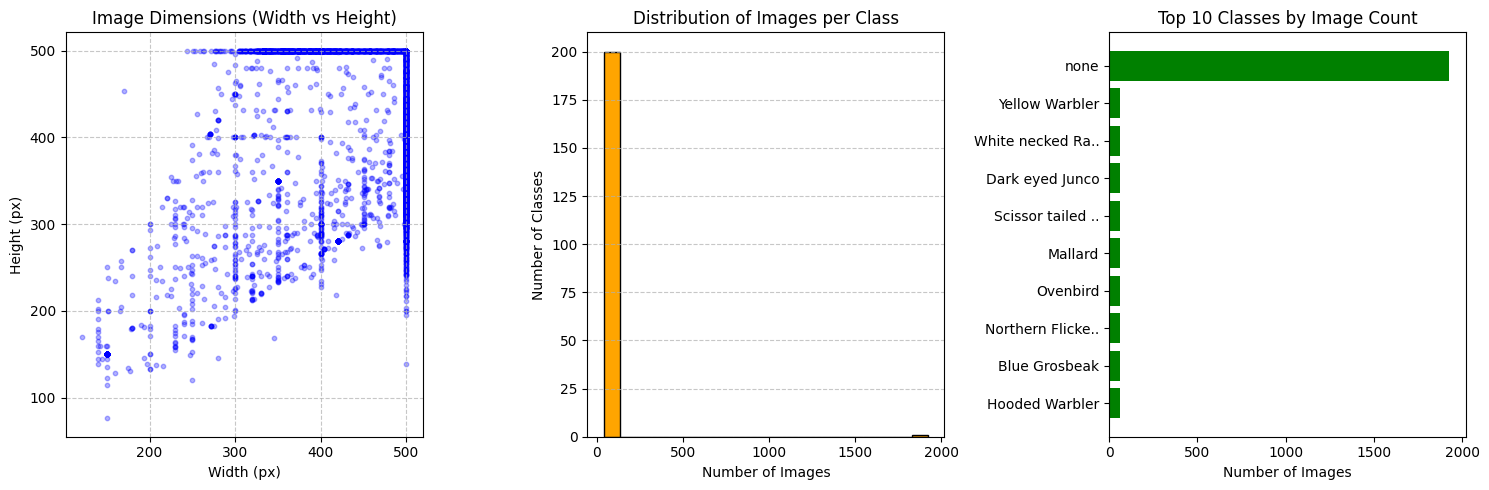

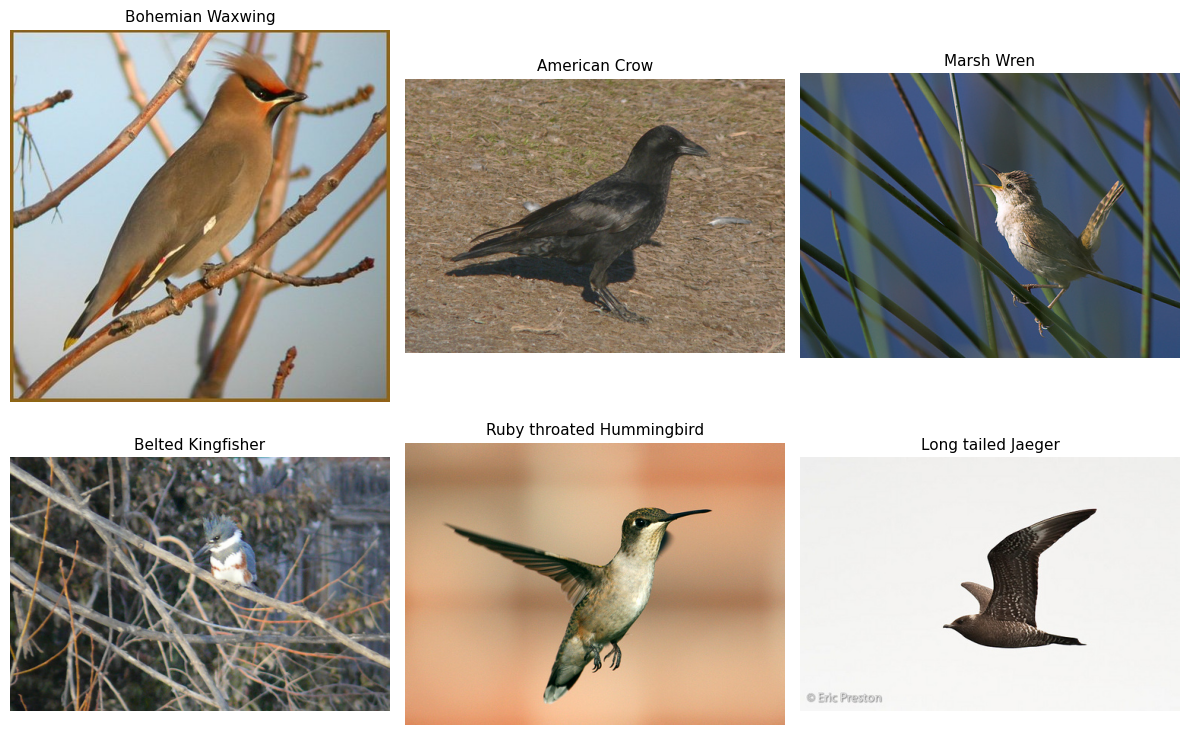

In [16]:
# data vizualization
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

data_path = '/content/CUB_200_dataset/CUB_200_2011/images'

image_extensions = {'.jpg', '.jpeg', '.png'}
image_sizes = []
class_counts = Counter()
all_image_paths = []


# gather image data
for root, dirs, files in os.walk(data_path):
    for file in files:
        if os.path.splitext(file)[1].lower() in image_extensions:
            img_path = os.path.join(root, file)
            all_image_paths.append(img_path)

            class_name = os.path.basename(root)
            # Clean up the name for readability
            clean_class_name = class_name.split('.')[-1].replace('_', ' ')
            class_counts[clean_class_name] += 1

            try:
                with Image.open(img_path) as img:
                    image_sizes.append(img.size) # (width, height)
            except Exception:
                pass

widths, heights = zip(*image_sizes)

# ---------------------------------------------------------
# PLOT 1: Scatter plot of image dimensions
# ---------------------------------------------------------
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(widths, heights, alpha=0.3, color='blue', s=10)
plt.title("Image Dimensions (Width vs Height)")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.grid(True, linestyle='--', alpha=0.7)

# ---------------------------------------------------------
# PLOT 2: Histogram of images per category
# ---------------------------------------------------------
plt.subplot(1, 3, 2)
# We expect this to be heavily clustered around ~60 images per class
plt.hist(class_counts.values(), bins=20, color='orange', edgecolor='black')
plt.title("Distribution of Images per Class")
plt.xlabel("Number of Images")
plt.ylabel("Number of Classes")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# ---------------------------------------------------------
# PLOT 3: Bar chart of top 10 categories with most images
# ---------------------------------------------------------
plt.subplot(1, 3, 3)
top_10_classes = class_counts.most_common(10)
names, counts = zip(*top_10_classes)

# shorten names if needed
short_names = [n[:15] + '..' if len(n) > 15 else n for n in names]

plt.barh(short_names, counts, color='green')
plt.title("Top 10 Classes by Image Count")
plt.xlabel("Number of Images")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PLOT 4: Grid of random sample images
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))

# 6 random images
random_images = random.sample(all_image_paths, 6)

for i, img_path in enumerate(random_images):
    img = Image.open(img_path)

    raw_class = os.path.basename(os.path.dirname(img_path))
    display_name = raw_class.split('.')[-1].replace('_', ' ')

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(display_name, fontsize=11)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [17]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, random_split

# Augmentations definition
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Define two datasets with different transformation
train_dataset_full = datasets.ImageFolder(data_path, transform=data_transforms['train'])
val_dataset_full = datasets.ImageFolder(data_path, transform=data_transforms['val'])

# Create dividing indices
indices = torch.randperm(len(train_dataset_full)).tolist()
train_size = int(0.8 * len(train_dataset_full))

train_idx = indices[:train_size]
val_idx = indices[train_size:]

# Create subsets, every subset uses different transformations
train_data = torch.utils.data.Subset(train_dataset_full, train_idx)
val_data = torch.utils.data.Subset(val_dataset_full, val_idx)

# Apply to loaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)

In [18]:
# Load pre-trained ResNet18
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_ft = models.resnet18(weights='IMAGENET1K_V1')

# Last layer modification (fc - fully connected)
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 201) # 200 - number of bird classes in dataset + 1 none

model_ft = model_ft.to(device)

# Loss function and optimization algorithm
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ft.parameters(), lr=0.001)

# DYNAMIC LR: Every 5 epochs, reduce LR by one floating point
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [19]:
# Check whether GPU acceleration is available and set up
#   RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU -> SAVE
if not torch.cuda.is_available():
    print('GPU not found. Try:')
    print('  - RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU -> SAVE')
else:
    device_name = torch.cuda.get_device_name(0)
    print(f'Success! GPU: {device_name}')

# Print GPU details
!nvidia-smi

Success! GPU: Tesla T4
Sat Apr 11 11:58:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P0             27W /   70W |     213MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------------------

In [20]:
import time

def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    time_start = time.time()

    for epoch in range(num_epochs):
        print(f'Epoch {epoch + 1}/{num_epochs}')
        print('----------')

        # Every epoch consists of training and validation phases
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
                dataset_size = len(train_data)
            else:
                model.eval()
                dataloader = val_loader
                dataset_size = len(val_data)

            running_loss = 0.0
            running_corrects = 0
            running_top5_corrects = 0

            # Iterate over data
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    _, top5_preds = outputs.topk(5, 1)
                    running_top5_corrects += (top5_preds == labels.view(-1, 1)).sum().item()

                    # Backward pass + optimization (only in training phase)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Decrease learning rate if condition satisfied
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_size
            epoch_acc = running_corrects.double() / dataset_size
            epoch_top5_acc = running_top5_corrects / dataset_size
            print(f'{phase}')
            print(f'  Loss: {epoch_loss:.4f}')
            print(f'  Accuracy: {epoch_acc:.4f}')
            print(f'  Acc-Top5: {epoch_top5_acc:.4f}')

        print()

    time_elapsed = time.time() - time_start
    print(f'Training finished in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    return model

# Run 15 epochs
model_ft = train_model(model_ft, criterion, optimizer, exp_lr_scheduler, num_epochs=15)

Epoch 1/15
----------
train
  Loss: 4.6032
  Accuracy: 0.1492
  Acc-Top5: 0.2046
val
  Loss: 4.9328
  Accuracy: 0.1105
  Acc-Top5: 0.2392

Epoch 2/15
----------
train
  Loss: 3.9347
  Accuracy: 0.1807
  Acc-Top5: 0.3073
val
  Loss: 3.5423
  Accuracy: 0.2169
  Acc-Top5: 0.3853

Epoch 3/15
----------
train
  Loss: 3.4186
  Accuracy: 0.2281
  Acc-Top5: 0.4241
val
  Loss: 3.1016
  Accuracy: 0.2734
  Acc-Top5: 0.4965

Epoch 4/15
----------
train
  Loss: 3.0907
  Accuracy: 0.2764
  Acc-Top5: 0.5155
val
  Loss: 2.8099
  Accuracy: 0.3347
  Acc-Top5: 0.6059

Epoch 5/15
----------
train
  Loss: 2.7794
  Accuracy: 0.3336
  Acc-Top5: 0.5977
val
  Loss: 2.4684
  Accuracy: 0.3795
  Acc-Top5: 0.6821

Epoch 6/15
----------
train
  Loss: 2.2288
  Accuracy: 0.4558
  Acc-Top5: 0.7156
val
  Loss: 1.6345
  Accuracy: 0.5600
  Acc-Top5: 0.8232

Epoch 7/15
----------
train
  Loss: 1.9995
  Accuracy: 0.4997
  Acc-Top5: 0.7511
val
  Loss: 1.5346
  Accuracy: 0.5815
  Acc-Top5: 0.8429

Epoch 8/15
----------
train

In [21]:
# az budeme chtit ukladat model
# torch.save(model_ft.state_dict(), '/content/drive/MyDrive/bird_resnet18.pth')